In [1]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
model = YOLO("runs/detect/train-8/weights/best.pt")

In [4]:
results = model("yolo_tiled/images/08a9d36e-page1_6.png") # conf=0.005


image 1/1 /Users/ihpar/Documents/Deve/omr/yolo_tiled/images/08a9d36e-page1_6.png: 1280x1280 2 barlines, 5 comma_4_downs, 12 comma_4_ups, 3 notehead_emptys, 45 notehead_filleds, 3 rests, 7 treble_clefs, 1129.2ms
Speed: 4.2ms preprocess, 1129.2ms inference, 0.2ms postprocess per image at shape (1, 3, 1280, 1280)


In [3]:
def visualize_tile(img_path):
    results = model(img_path) # conf=0.005
    res = results[0]
    img = res.orig_img.copy()

    # -----------------------------
    # Class names (your YAML order)
    # -----------------------------

    CLASS_NAMES = [
        "barline",
        "comma_1_down",
        "comma_4_down",
        "comma_4_up",
        "natural",
        "notehead_empty",
        "notehead_filled",
        "rest",
        "treble_clef"
    ]

    # -----------------------------
    # Color map (fixed per class)
    # -----------------------------

    np.random.seed(2)
    COLORS = np.random.randint(0, 255, size=(len(CLASS_NAMES), 3))

    # -----------------------------
    # Count present classes
    # -----------------------------

    class_ids = [int(b.cls[0]) for b in res.boxes]
    counts = Counter(class_ids)
    present_classes = sorted(counts.keys())

    # -----------------------------
    # Draw transparent overlays
    # -----------------------------

    overlay = img.copy()
    alpha = 0.3  # transparency level

    for box in res.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = tuple(map(int, COLORS[cls]))

        # Filled transparent rectangle
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)

        # Thin border on original image
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 1)

    # Blend overlay with original
    img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    # -----------------------------
    # Create legend (only present classes)
    # -----------------------------

    legend_width = 300
    legend = np.ones((img.shape[0], legend_width, 3), dtype=np.uint8) * 255

    y_offset = 30

    for cls in present_classes:
        name = CLASS_NAMES[cls]
        color = tuple(map(int, COLORS[cls]))
        count = counts[cls]

        # Color box
        cv2.rectangle(
            legend,
            (10, y_offset - 15),
            (30, y_offset + 5),
            color,
            -1
        )

        # Text with count
        cv2.putText(
            legend,
            f"{name} ({count})",
            (40, y_offset),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 0),
            1,
            cv2.LINE_AA
        )

        y_offset += 25

    # -----------------------------
    # Combine image + legend
    # -----------------------------

    combined = np.hstack((img, legend))


    img_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()


image 1/1 /Users/ihpar/Documents/Deve/omr/tiled_test/page1_3.png: 1280x1280 8 barlines, 5 comma_4_downs, 11 comma_4_ups, 48 notehead_filleds, 6 treble_clefs, 1341.8ms
Speed: 7.2ms preprocess, 1341.8ms inference, 1.7ms postprocess per image at shape (1, 3, 1280, 1280)


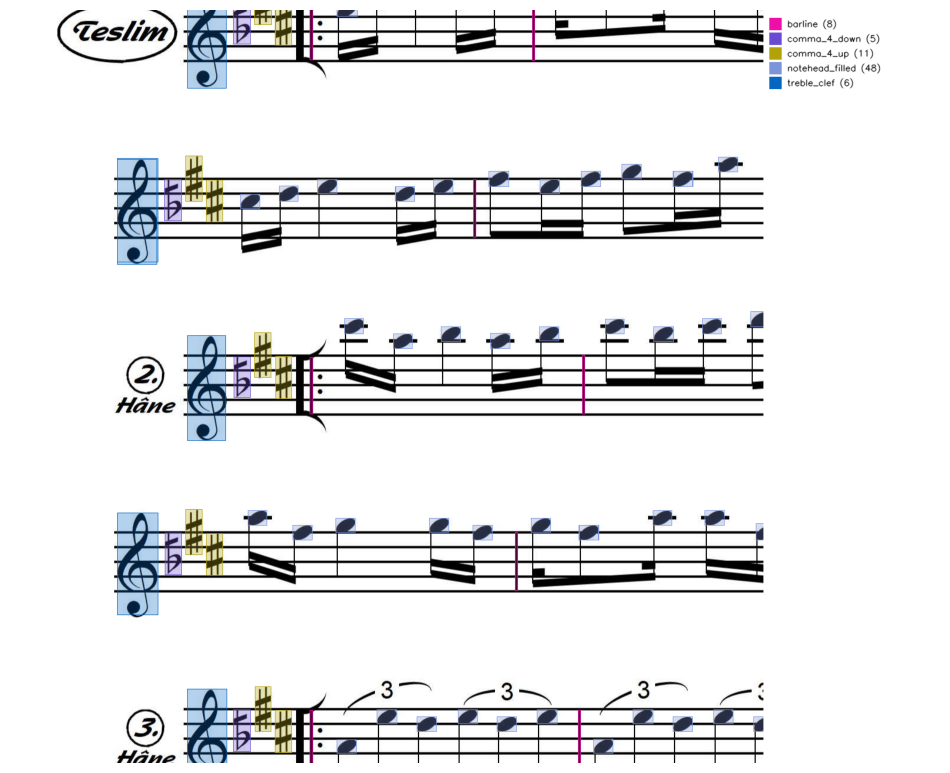

In [4]:
visualize_tile("tiled_test/page1_3.png")

Processing: page1_0.png

image 1/1 /Users/ihpar/Documents/Deve/omr/tiled_test/page1_0.png: 1280x1280 4 barlines, 3 comma_4_downs, 6 comma_4_ups, 1 natural, 33 notehead_filleds, 3 treble_clefs, 1108.1ms
Speed: 5.7ms preprocess, 1108.1ms inference, 0.2ms postprocess per image at shape (1, 3, 1280, 1280)
Processing: page1_1.png

image 1/1 /Users/ihpar/Documents/Deve/omr/tiled_test/page1_1.png: 1280x1280 8 barlines, 2 comma_4_ups, 3 naturals, 2 notehead_emptys, 50 notehead_filleds, 1104.7ms
Speed: 5.3ms preprocess, 1104.7ms inference, 0.1ms postprocess per image at shape (1, 3, 1280, 1280)
Processing: page1_10.png

image 1/1 /Users/ihpar/Documents/Deve/omr/tiled_test/page1_10.png: 448x1280 3 barlines, 1 comma_4_down, 13 notehead_filleds, 351.3ms
Speed: 1.6ms preprocess, 351.3ms inference, 0.1ms postprocess per image at shape (1, 3, 448, 1280)
Processing: page1_11.png

image 1/1 /Users/ihpar/Documents/Deve/omr/tiled_test/page1_11.png: 1280x1280 1 barline, 1 notehead_filled, 1118.6ms
Speed: 

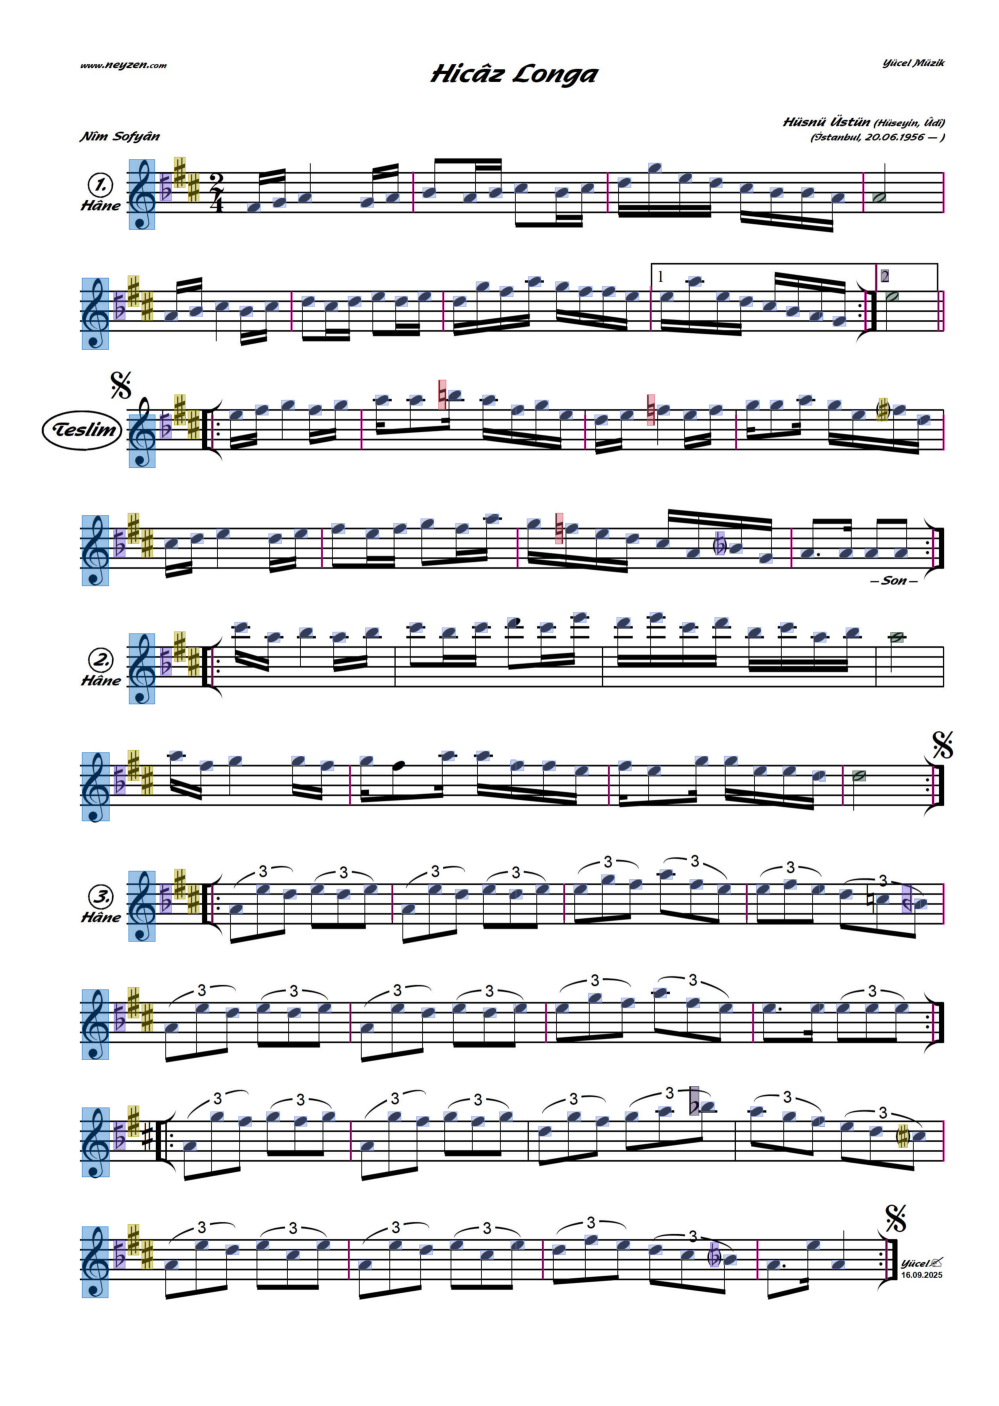

In [6]:
# -----------------------------
# SETTINGS
# -----------------------------

# TILE_DIR = "yolo_tiled/images"
TILE_DIR = "tiled_test"

ORIG_W = 2480
ORIG_H = 3508

TILE_SIZE = 1280
OVERLAP = 256
STRIDE = TILE_SIZE - OVERLAP

CONF_THRES = 0.4
IOU_NMS = 0.5

# -----------------------------
# Helper: parse tile index → (row, col)
# -----------------------------


def get_tile_position(tile_idx, img_w, img_h):
    tiles_x = int(np.ceil((img_w - TILE_SIZE) / STRIDE)) + 1

    row = tile_idx // tiles_x
    col = tile_idx % tiles_x

    x_offset = col * STRIDE
    y_offset = row * STRIDE

    return x_offset, y_offset

# -----------------------------
# Collect all detections
# -----------------------------


all_boxes = []
all_scores = []
all_classes = []

tile_files = sorted(os.listdir(TILE_DIR))

for tile_file in tile_files:

    # if not tile_file.endswith(".png") or (not tile_file.startswith("08a")):
    if not tile_file.endswith(".png"):
        continue

    print("Processing:", tile_file)

    tile_idx = int(tile_file.split("_")[-1].replace(".png", ""))

    x_offset, y_offset = get_tile_position(tile_idx, ORIG_W, ORIG_H)

    path = os.path.join(TILE_DIR, tile_file)

    results = model(path, conf=CONF_THRES)[0]

    for box in results.boxes:

        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        # shift to global coords
        x1 += x_offset
        x2 += x_offset
        y1 += y_offset
        y2 += y_offset

        all_boxes.append([x1, y1, x2, y2])
        all_scores.append(conf)
        all_classes.append(cls)

all_boxes = np.array(all_boxes)
all_scores = np.array(all_scores)
all_classes = np.array(all_classes)

print("Before NMS:", len(all_boxes))

# -----------------------------
# Apply class-wise NMS
# -----------------------------

final_boxes = []
final_scores = []
final_classes = []

for cls in np.unique(all_classes):

    idxs = np.where(all_classes == cls)[0]

    boxes_cls = all_boxes[idxs]
    scores_cls = all_scores[idxs]

    boxes_xywh = []

    for b in boxes_cls:
        x1, y1, x2, y2 = b
        boxes_xywh.append([x1, y1, x2-x1, y2-y1])

    indices = cv2.dnn.NMSBoxes(
        boxes_xywh,
        scores_cls.tolist(),
        score_threshold=CONF_THRES,
        nms_threshold=IOU_NMS
    )

    if len(indices) > 0:
        for i in indices.flatten():
            final_boxes.append(boxes_cls[i])
            final_scores.append(scores_cls[i])
            final_classes.append(cls)

print("After NMS:", len(final_boxes))

# -----------------------------
# Visualization
# -----------------------------

# create blank canvas
# canvas = np.ones((ORIG_H, ORIG_W, 3), dtype=np.uint8) * 255
# original_img = cv2.imread("yolo_init/images/08a9d36e-page1.png")
original_img = cv2.imread("dataset/img/neyzen_com/hicaz/hicaz_longa_husnu_ustun_udi_huseyin/page1.png")
canvas = original_img.copy()

# random colors
np.random.seed(2)
COLORS = np.random.randint(0, 255, size=(50, 3))

overlay = canvas.copy()
alpha = 0.4

for (x1, y1, x2, y2), cls in zip(final_boxes, final_classes):
    color = tuple(map(int, COLORS[cls]))

    # filled transparent box
    cv2.rectangle(overlay, (int(x1), int(y1)), (int(x2), int(y2)), color, -1)

    # thin border
    cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), color, 1)

canvas = cv2.addWeighted(overlay, alpha, canvas, 1 - alpha, 0)

cv2.imwrite("output_image_test.png", canvas)

img_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 18))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()